# **Hyperparameter Optimization & Training Analysis**
Stable Version for Copying

## Hyperparameter Optimization Analysis

In [1]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import sys
import optuna
import yaml

from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

try:
    from config import RUNS_DIR
except ImportError:
    print("Warning: Could not import RUNS_DIR. Ensure config.py is in the root directory.")


STUDY_FOLDER = "acne_hparam_study_v2"
STUDY_PREFIX = "acne_hparam_search_v2_trial_"
study_path = RUNS_DIR / STUDY_FOLDER

In [2]:
records = []

if not study_path.exists():
    raise FileNotFoundError(f"Check paths. Could not find: {study_path}")

for trial_dir in study_path.glob(f"{STUDY_PREFIX}*"):
    args_path = trial_dir / "args.yaml"
    results_path = trial_dir / "results.csv"

    if not args_path.exists() or not results_path.exists():
        continue

    # Load params
    with open(args_path, "r") as f:
        args = yaml.safe_load(f)

    # Load metrics
    df = pd.read_csv(results_path)
    if df.empty:
        continue

    df.columns = [c.strip() for c in df.columns]
    final_row = df.iloc[-1]

    record = {
        "trial": trial_dir.name,
        "map50": final_row.get("metrics/mAP50(B)", None),
        "map50_95": final_row.get("metrics/mAP50-95(B)", None),
        "precision": final_row.get("metrics/precision(B)", None),
        "recall": final_row.get("metrics/recall(B)", None),

        "optimizer": args.get("optimizer"),
        "lr0": args.get("lr0"),
        "weight_decay": args.get("weight_decay"),
        "mosaic": args.get("mosaic"),
        "mixup": args.get("mixup"),
        "hsv_s": args.get("hsv_s"),
        "hsv_v": args.get("hsv_v"),
        "scale": args.get("scale"),
    }

    records.append(record)

results = pd.DataFrame(records)

In [3]:
print(f"Loaded {len(results)} trials from {STUDY_FOLDER}")

print("\nTop 10 Trials by Recall:")
display(results.sort_values("recall", ascending=False).head(10))

top_5_trials = results.sort_values("recall", ascending=False).head(5)

Loaded 14 trials from acne_hparam_study_v2

Top 10 Trials by Recall:


,trial,map50,map50_95,precision,recall,optimizer,lr0,weight_decay,mosaic,mixup,hsv_s,hsv_v,scale
0,acne_hparam_search_v2_trial_0,0.39782,0.14094,0.47123,0.44000,AdamW,0.001959,0.002331,0.532219,0.027834,0.078545,0.240186,0.511213
11,acne_hparam_search_v2_trial_21,0.37944,0.13045,0.47330,0.43792,AdamW,0.000090,0.000289,0.523675,0.064740,0.339236,0.162289,0.300628
2,acne_hparam_search_v2_trial_13,0.39671,0.13696,0.47745,0.43333,AdamW,0.000657,0.000011,0.297129,0.067693,0.209832,0.287911,0.456351
3,acne_hparam_search_v2_trial_14,0.39877,0.13853,0.48723,0.41768,AdamW,0.000039,0.001212,0.312381,0.030539,0.001562,0.205145,0.563482
9,acne_hparam_search_v2_trial_2,0.39247,0.13336,0.49491,0.41708,AdamW,0.000031,0.002178,0.054430,0.022516,0.212155,0.058059,0.515450
8,acne_hparam_search_v2_trial_19,0.38332,0.13705,0.46214,0.41417,AdamW,0.000481,0.009231,0.561149,0.034572,0.201987,0.100518,0.514100
5,acne_hparam_search_v2_trial_16,0.35875,0.12200,0.42526,0.41083,AdamW,0.000010,0.000806,0.476161,0.004030,0.349350,0.173956,0.626450
6,acne_hparam_search_v2_trial_17,0.37042,0.12873,0.42983,0.40667,AdamW,0.000021,0.000443,0.481597,0.062602,0.109121,0.237705,0.306065
7,acne_hparam_search_v2_trial_18,0.37347,0.13036,0.46680,0.40625,AdamW,0.000018,0.000519,0.432907,0.062252,0.107073,0.229121,0.620904
4,acne_hparam_search_v2_trial_15,0.36149,0.12379,0.44264,0.40417,AdamW,0.000015,0.000694,0.422017,0.067724,0.321819,0.171355,0.613544


In [4]:
# CORRELATION ANALYSIS 
numeric_cols = [
    "lr0",
    "weight_decay",
    "mosaic",
    "mixup",
    "hsv_s",
    "hsv_v",
    "scale",
    "map50"
]

existing_cols = [c for c in numeric_cols if c in results.columns]
corr = results[existing_cols].corr()

print("\nCorrelation with mAP50:")
display(corr["map50"].sort_values(ascending=False))


Correlation with mAP50:


map50           1.000000
weight_decay    0.274510
hsv_v           0.175331
lr0             0.157730
mixup           0.154630
scale           0.020197
mosaic         -0.031400
hsv_s          -0.255389
Name: map50, dtype: float64

In [5]:
# BEST TRIAL SUMMARY 

print("BEST TRIAL (Highest Recall)\n")

best = results.sort_values("recall", ascending=False).iloc[0]
print(best)

BEST TRIAL (Highest Recall)

trial           acne_hparam_search_v2_trial_0
map50                                 0.39782
map50_95                              0.14094
precision                             0.47123
recall                                   0.44
optimizer                               AdamW
lr0                                  0.001959
weight_decay                         0.002331
mosaic                               0.532219
mixup                                0.027834
hsv_s                                0.078545
hsv_v                                0.240186
scale                                0.511213
Name: 0, dtype: object



Comprehensive Metric and Loss Profiles for Top 5 Trials


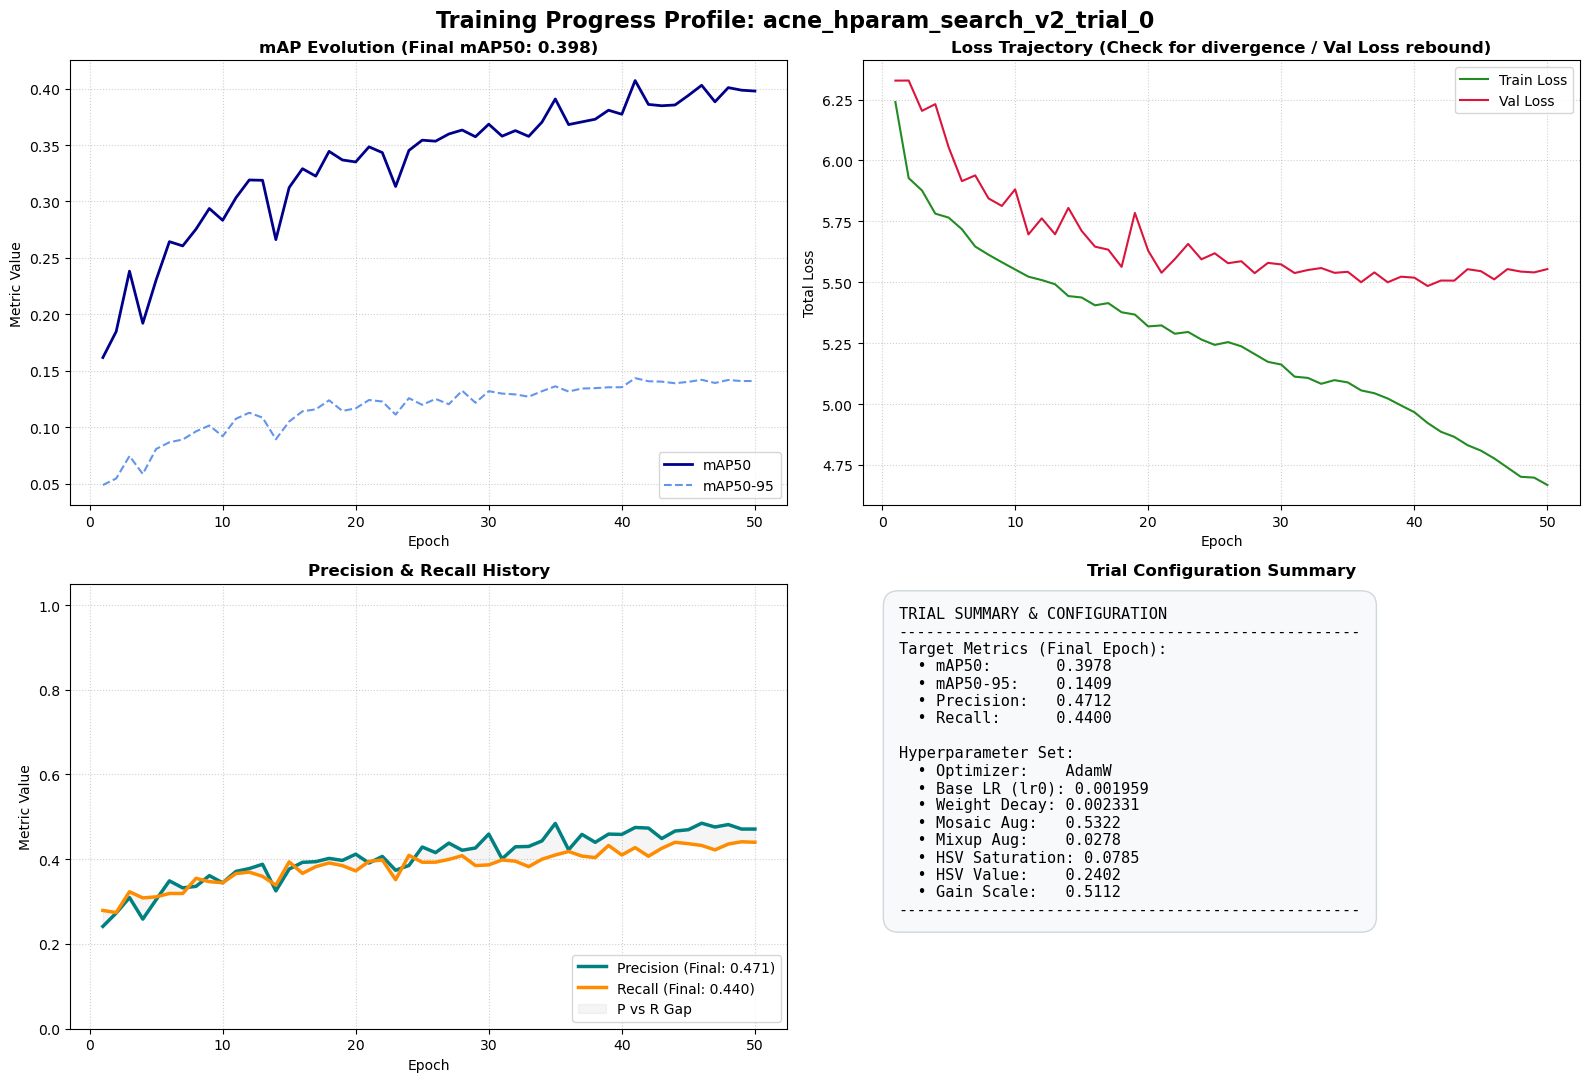

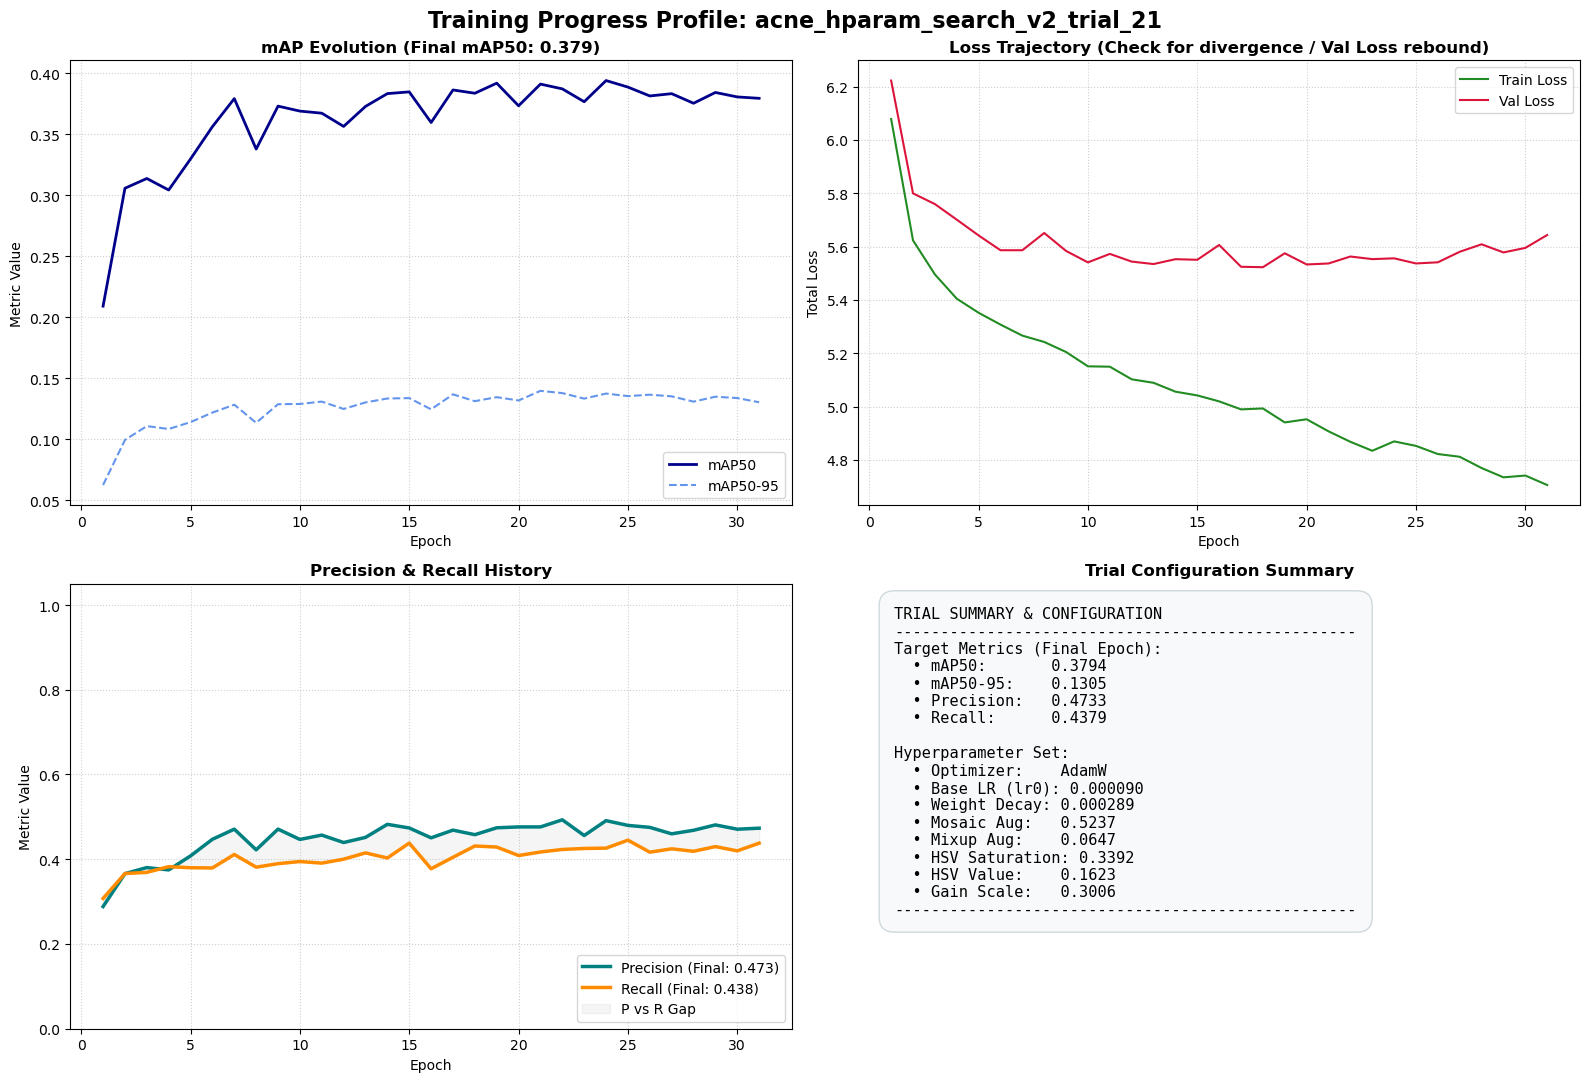

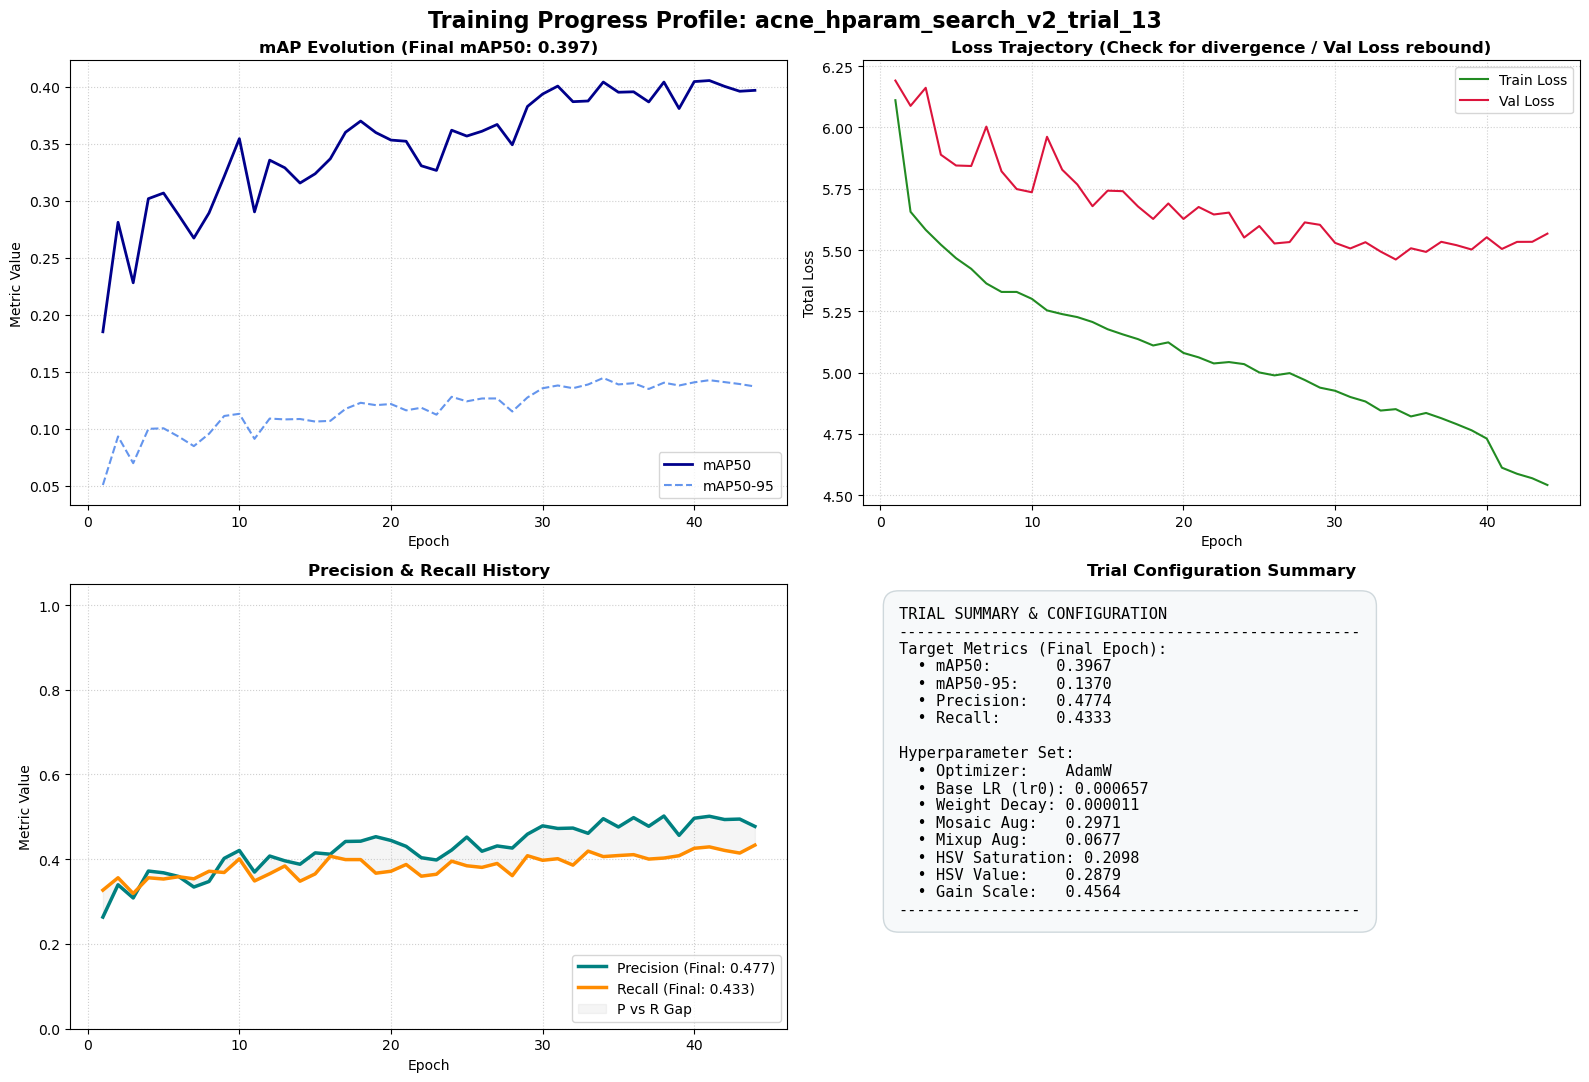

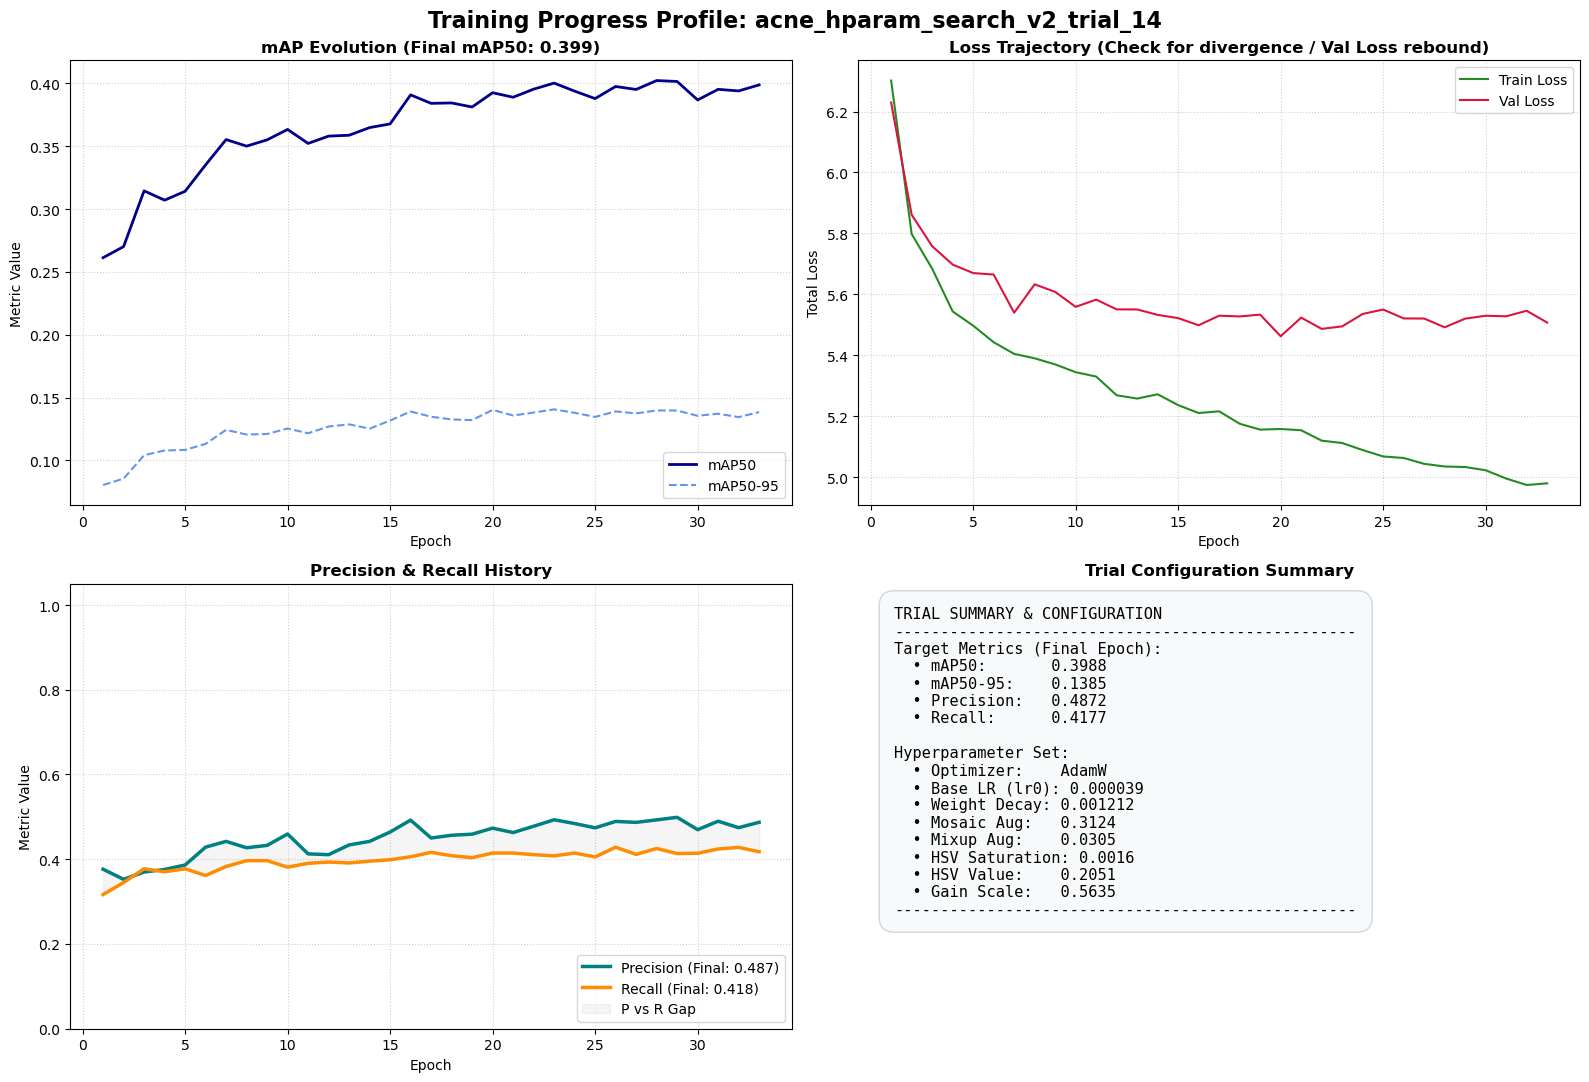

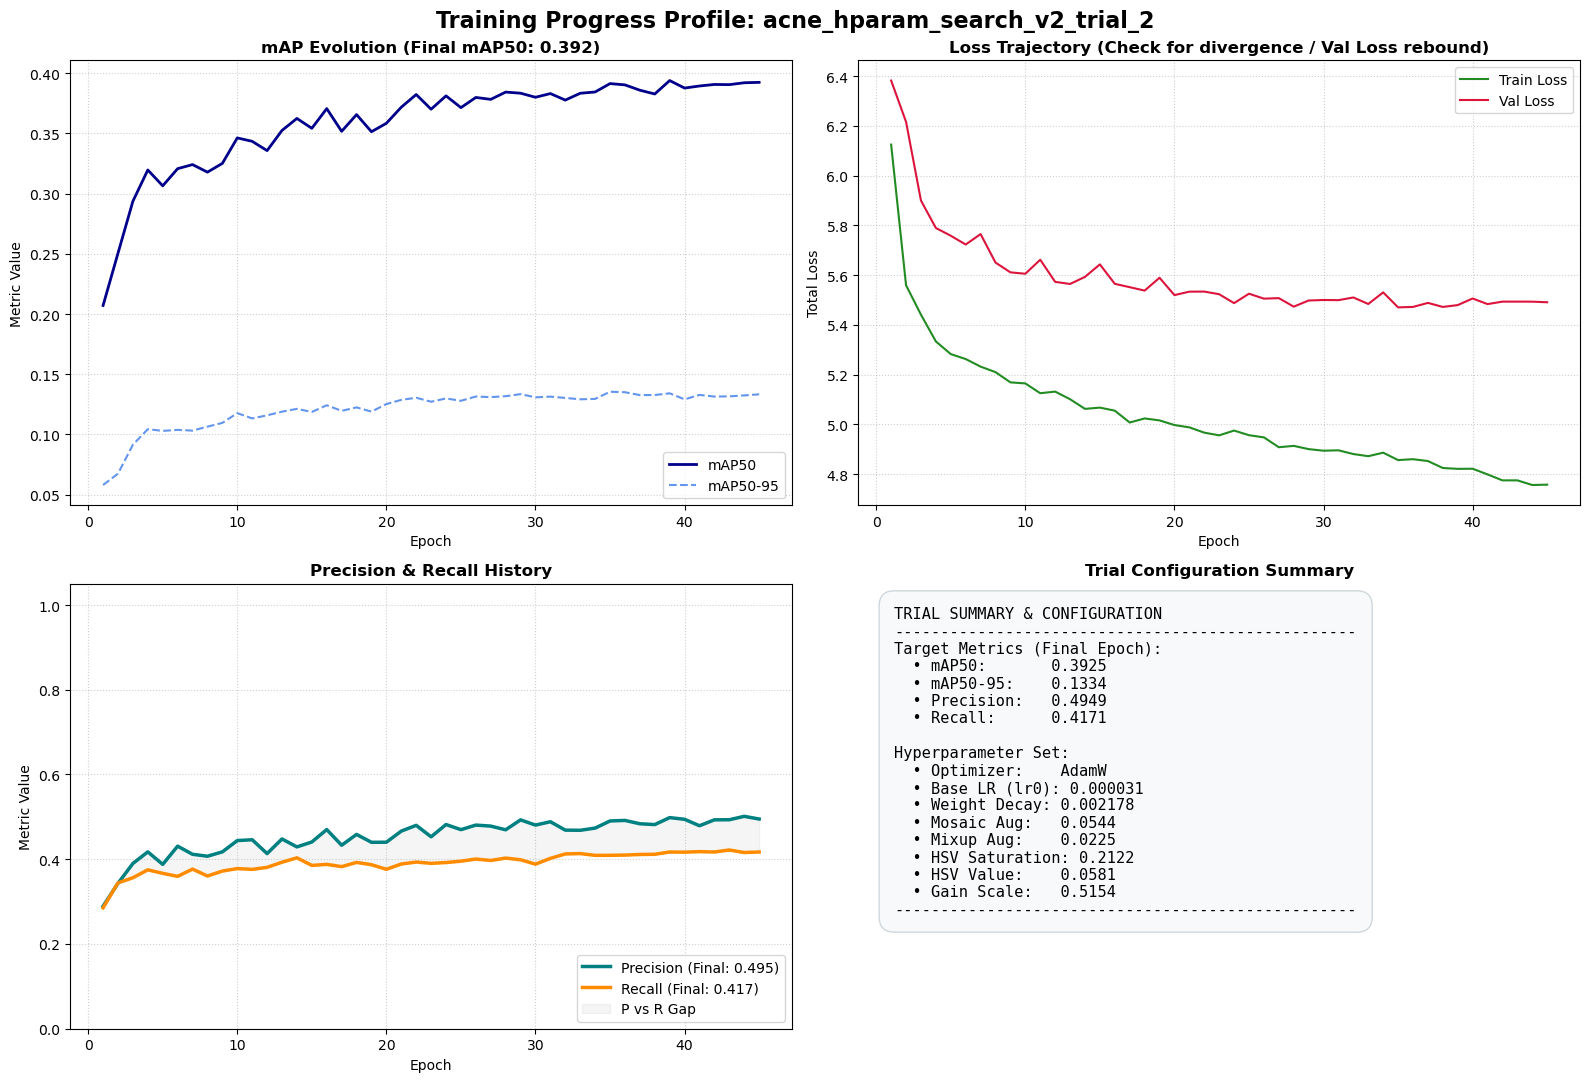

In [ ]:
print("\nComprehensive Metric and Loss Profiles for Top 5 Trials")

for idx, row in top_5_trials.iterrows():
    t_name = row["trial"]
    res_df = pd.read_csv(study_path / t_name / "results.csv")
    res_df.columns = [c.strip() for c in res_df.columns]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle(f"Training Progress Profile: {t_name}", fontsize=16, fontweight='bold', y=0.98)
    
    # Row 1, Left: mAP Evolution 
    axes[0, 0].plot(res_df["epoch"], res_df["metrics/mAP50(B)"], color="darkblue", linewidth=2, label="mAP50")
    if "metrics/mAP50-95(B)" in res_df.columns:
        axes[0, 0].plot(res_df["epoch"], res_df["metrics/mAP50-95(B)"], color="cornflowerblue", linestyle="--", label="mAP50-95")
        
    axes[0, 0].set_title(f"mAP Evolution (Final mAP50: {row['map50']:.3f})", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Metric Value")
    axes[0, 0].legend(loc="lower right")
    axes[0, 0].grid(True, linestyle=":", alpha=0.6)
    
    # Row 1, Right: Train vs Validation Loss Comparison 
    train_loss_cols = [c for c in ["train/box_loss", "train/cls_loss", "train/dfl_loss"] if c in res_df.columns]
    val_loss_cols = [c for c in ["val/box_loss", "val/cls_loss", "val/dfl_loss"] if c in res_df.columns]
    
    if train_loss_cols and val_loss_cols:
        total_train_loss = res_df[train_loss_cols].sum(axis=1)
        total_val_loss = res_df[val_loss_cols].sum(axis=1)
        
        axes[0, 1].plot(res_df["epoch"], total_train_loss, color="forestgreen", label="Train Loss")
        axes[0, 1].plot(res_df["epoch"], total_val_loss, color="crimson", label="Val Loss")
        axes[0, 1].set_title("Loss Trajectory (Check for divergence / Val Loss rebound)", fontsize=12, fontweight='bold')
    else:
        axes[0, 1].text(0.5, 0.5, "Loss columns missing in results file", ha='center', va='center')
        
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Total Loss")
    axes[0, 1].legend(loc="upper right")
    axes[0, 1].grid(True, linestyle=":", alpha=0.6)
    
    # Row 2, Left: Precision and Recall Evolution 
    p_hist = res_df["metrics/precision(B)"].values
    r_hist = res_df["metrics/recall(B)"].values
    epochs = res_df["epoch"].values
    
    axes[1, 0].plot(epochs, p_hist, color="teal", linewidth=2.5, label=f"Precision (Final: {row['precision']:.3f})")
    axes[1, 0].plot(epochs, r_hist, color="darkorange", linewidth=2.5, label=f"Recall (Final: {row['recall']:.3f})")
    axes[1, 0].fill_between(epochs, p_hist, r_hist, color="gray", alpha=0.08, label="P vs R Gap")
    
    axes[1, 0].set_title("Precision & Recall History", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Metric Value")
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].legend(loc="lower right")
    axes[1, 0].grid(True, linestyle=":", alpha=0.6)
    
    # Row 2, Right: Configuration & Metric Summary Card 
    axes[1, 1].axis('off')
    
    summary_text = (
        f"TRIAL SUMMARY & CONFIGURATION\n"
        f"--------------------------------------------------\n"
        f"Target Metrics (Final Epoch):\n"
        f"  • mAP50:       {row['map50']:.4f}\n"
        f"  • mAP50-95:    {row['map50_95']:.4f}\n"
        f"  • F1-Score:    {row['f1_score']:.4f}\n"
        f"  • Precision:   {row['precision']:.4f}\n"
        f"  • Recall:      {row['recall']:.4f}\n\n"
        f"Hyperparameter Set:\n"
        f"  • Optimizer:    {row['optimizer']}\n"
        f"  • Base LR (lr0): {row['lr0']:.6f}\n"
        f"  • Weight Decay: {row['weight_decay']:.6f}\n"
        f"  • Mosaic Aug:   {row['mosaic']:.4f}\n"
        f"  • Mixup Aug:    {row['mixup']:.4f}\n"
        f"  • HSV Saturation: {row['hsv_s']:.4f}\n"
        f"  • HSV Value:    {row['hsv_v']:.4f}\n"
        f"  • Gain Scale:   {row['scale']:.4f}\n"
        f"--------------------------------------------------"
    )
    
    axes[1, 1].text(
        0.05, 0.95, summary_text, 
        fontsize=11, 
        fontfamily='monospace', 
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=1', facecolor='#f7f9fa', edgecolor='#cfd8dc', alpha=1.0)
    )
    axes[1, 1].set_title("Trial Configuration Summary", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Cell below is expotrs hyperparameters - it extracts specific settings from an Optuna database and saves them to a YAML file for final model training

In [ ]:
STUDY_FOLDER = "acne_hparam_study_v2"
STUDY_NAME = "acne_hparam_search_v2"
SELECTED_TRIAL_NUMBER = 0  # index of the trial to export 

db_path = RUNS_DIR / STUDY_FOLDER / f"{STUDY_NAME}.db"
storage_url = f"sqlite:///{db_path.resolve()}"

try:
    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=storage_url
    )
except Exception as e:
    print(f"Error loading study: {e}")
    print(f"Check if database exists at: {db_path}")
    raise

trial = study.trials[SELECTED_TRIAL_NUMBER]

if trial.state != optuna.trial.TrialState.COMPLETE:
    print(f"WARNING: Trial {SELECTED_TRIAL_NUMBER} state is {trial.state.name}")
    print("Parameters might be incomplete or the trial failed.")

params_to_save = trial.params

metadata = {
    "trial_index": SELECTED_TRIAL_NUMBER,
    "mAP50": trial.values[0] if trial.values else "N/A",
    "state": trial.state.name
}

full_config = {**params_to_save}

save_name = f"params_{STUDY_NAME}_trial_{SELECTED_TRIAL_NUMBER}.yaml"
save_path = RUNS_DIR / STUDY_FOLDER / save_name

with open(save_path, "w") as f:
    yaml.dump(full_config, f, default_flow_style=False, sort_keys=False)

print(f"Successfully exported parameters to: {save_path}")
print(yaml.dump(full_config, sort_keys=False))

Successfully exported parameters to: D:\studia\DermaAI\Models\runs\acne_hparam_study_v2\params_acne_hparam_search_v2_trial_0.yaml
lr0: 0.001959296019179874
weight_decay: 0.0023309838429649435
mosaic: 0.5322193484168319
mixup: 0.02783380060270344
hsv_s: 0.07854499548190713
hsv_v: 0.2401859523063922
scale: 0.5112131704940412
degrees: 1.4652180073029653



## Final Model Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from config import RUNS_DIR

RUN_NAME = "acne_train_production_v2"
RUN_DIR = RUNS_DIR / RUN_NAME
RESULTS_FILE = RUN_DIR / "results.csv"

if not RESULTS_FILE.exists():
    raise FileNotFoundError(f"Missing results file: {RESULTS_FILE}")

df = pd.read_csv(RESULTS_FILE)
df.columns = df.columns.str.strip() 

print(f"Loaded training data for: {RUN_NAME}")
print(f"Epochs trained: {len(df)}")



Loaded training data for: acne_train_production_v2
Epochs trained: 94


BEST EPOCH

epoch with best detection quality (highest recall)

In [ ]:
best_epoch_idx = df["metrics/recall(B)"].idxmax()
best_metrics = df.loc[best_epoch_idx, [
    "metrics/precision(B)", 
    "metrics/recall(B)", 
    "metrics/mAP50(B)", 
    "metrics/mAP50-95(B)"
]]

print(f"Best Epoch: {best_epoch_idx}")
print(best_metrics)

Best Epoch: 85
metrics/precision(B)    0.47108
metrics/recall(B)       0.45831
metrics/mAP50(B)        0.39397
metrics/mAP50-95(B)     0.13288
Name: 85, dtype: float64


LOSS CURVES

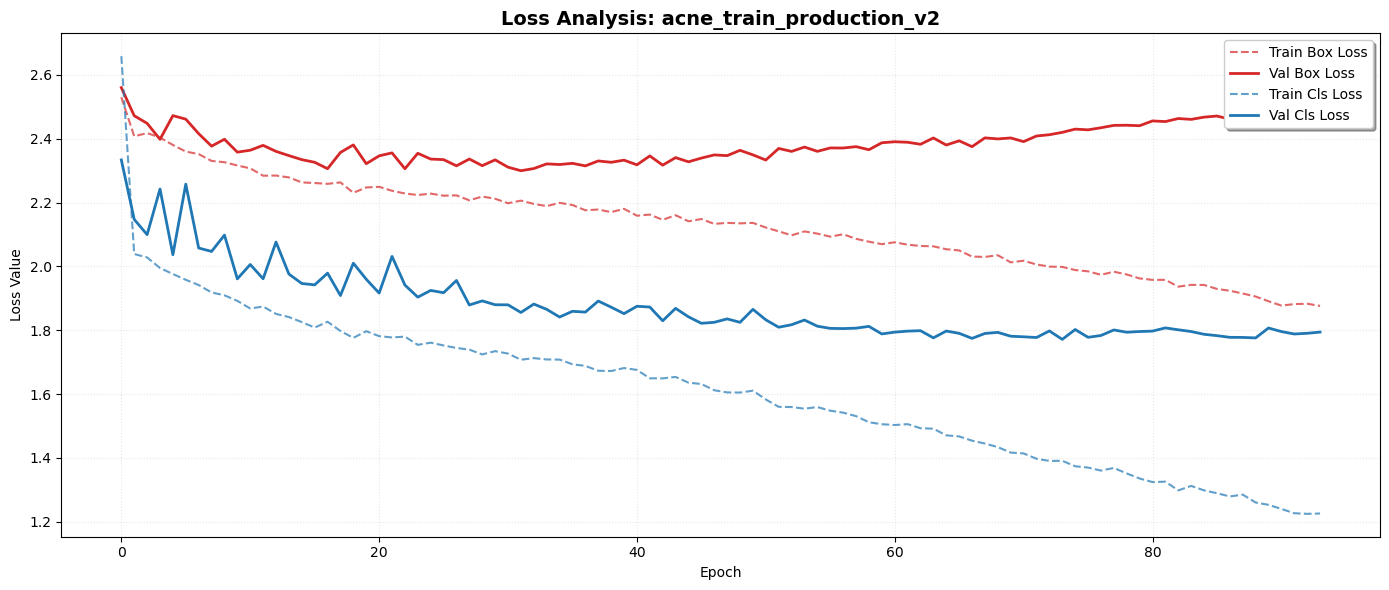

In [ ]:
plt.figure(figsize=(14, 6))

# Box Loss: measures how accurately the model draws the boxes
plt.plot(df["train/box_loss"], label="Train Box Loss", color='tab:red', linestyle='--', alpha=0.7)
plt.plot(df["val/box_loss"], label="Val Box Loss", color='tab:red', linewidth=2)

# Class Loss: measures how accurately the model identifies the acne type (not used for now)
plt.plot(df["train/cls_loss"], label="Train Cls Loss", color='tab:blue', linestyle='--', alpha=0.7)
plt.plot(df["val/cls_loss"], label="Val Cls Loss", color='tab:blue', linewidth=2)

plt.title(f"Loss Analysis: {RUN_NAME}", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")


plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

# Parallel Trends: If both dashed and solid lines drop together -> Good learning
# Widening Gap: If train goes down but val goes up -> Overfitting 
# Flat Cls Loss Line: If Cls loss doesnt drop -> Model is struggling to distinguish classes
# Noisy Lines: If Val loss jumps wildly -> Learning rate might be too high

MAIN METRICS

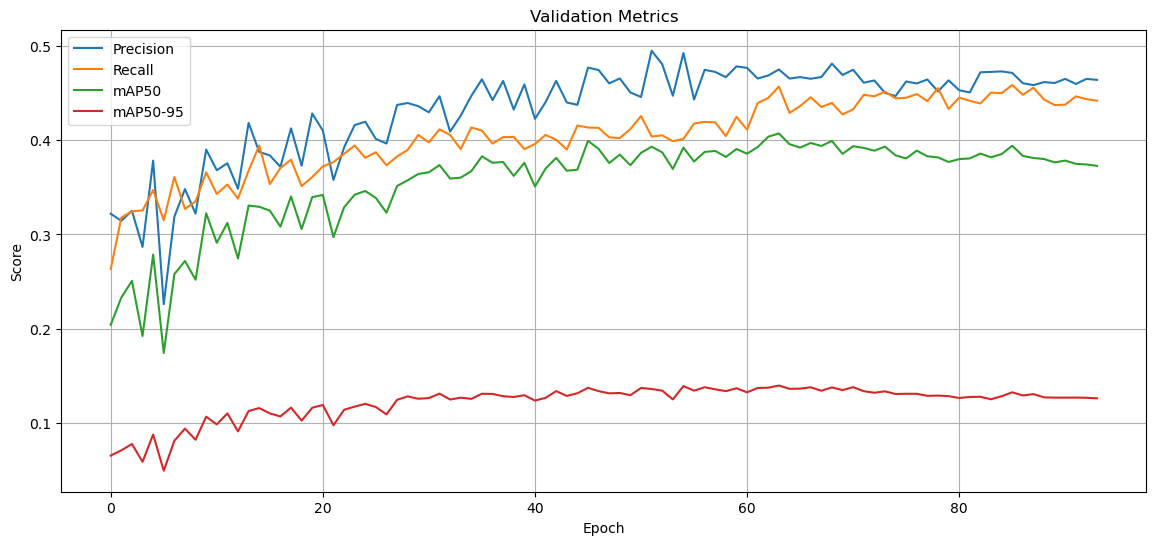

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["metrics/precision(B)"], label="Precision")
plt.plot(df["metrics/recall(B)"], label="Recall")
plt.plot(df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

LEARNING RATE

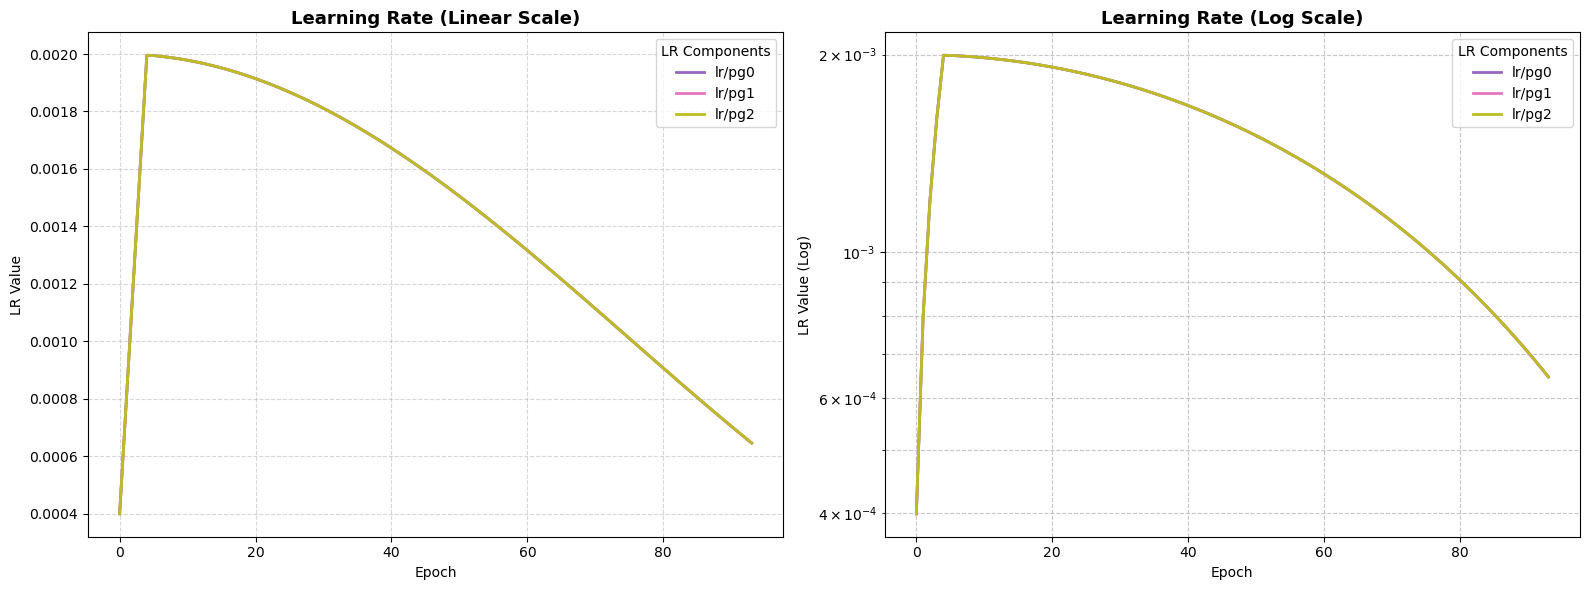

In [ ]:
# Learning rate schedule

lr_cols = [c for c in df.columns if "lr/" in c]

if lr_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = ['tab:purple', 'tab:pink', 'tab:olive']

    for i, col in enumerate(lr_cols):
        color = colors[i % len(colors)]
        ax1.plot(df[col], label=col, color=color, linewidth=2)
        ax2.plot(df[col], label=col, color=color, linewidth=2)

    # Subplot 1: Linear Scale
    ax1.set_title("Learning Rate (Linear Scale)", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("LR Value")
    ax1.grid(True, which="both", linestyle='--', alpha=0.5)
    ax1.legend(title="LR Components")

    # Subplot 2: Log Scale ( handles very small values)
    ax2.set_yscale('log')
    ax2.set_title("Learning Rate (Log Scale)", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("LR Value (Log)")
    ax2.grid(True, which="both", linestyle='--', alpha=0.7)
    ax2.legend(title="LR Components")

    plt.tight_layout()
    plt.show()

# The LR schedule is well-configured

GENERALIZATION GAP

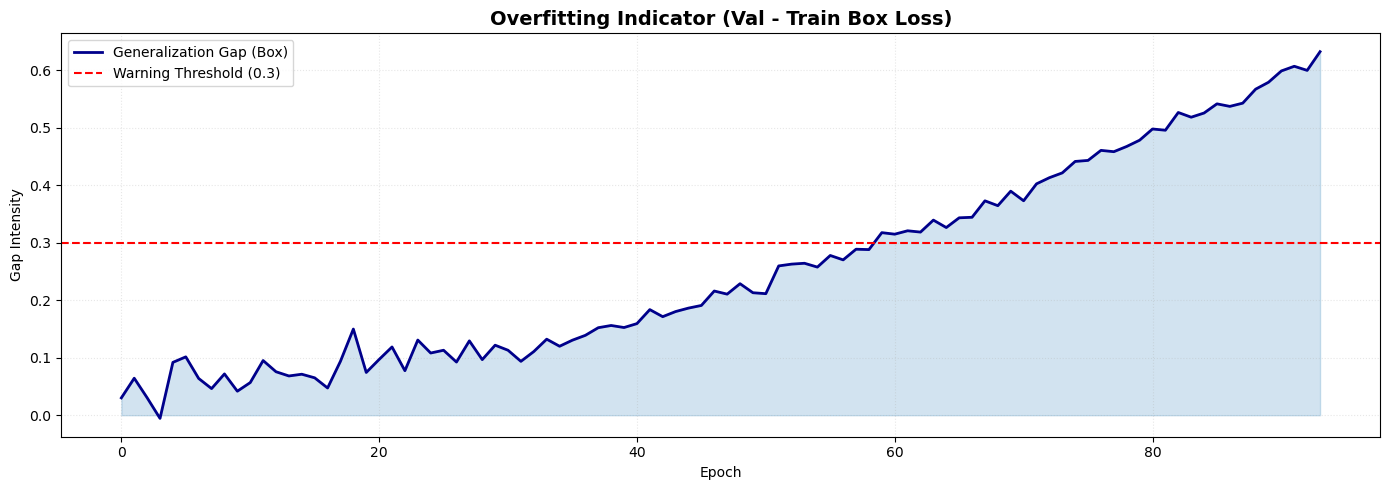

In [ ]:
# Difference between validation and training loss
# Positive gap -> possible overfitting
# Stable/low gap -> good generalization

if "train/box_loss" in df.columns and "val/box_loss" in df.columns:
    gap = df["val/box_loss"] - df["train/box_loss"]
    
    plt.figure(figsize=(14, 5))
    plt.fill_between(range(len(gap)), gap, alpha=0.2, color='tab:blue')
    plt.plot(gap, color='darkblue', linewidth=2, label="Generalization Gap (Box)")
    
    # Critical Overfitting Threshold - if gap exceeds this, model is likely memorizing training data
    plt.axhline(y=0.3, color='red', linestyle='--', label="Warning Threshold (0.3)")
    
    plt.title("Overfitting Indicator (Val - Train Box Loss)", fontsize=14, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("Gap Intensity")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()

    # SHOULD BE 0.1 - 0.3 
    # model memorized the training photos instead of learning (data leakage!!!) 